# Taller 3: Aprendizaje por Refuerzo en Triqui

**Curso:** Técnicas de Inteligencia Artificial  
**Universidad Nacional de Colombia - Sede Bogotá**  
**Ingeniería Mecatrónica - Facultad de Ingeniería**  
**Profesor:** Flavio Prieto - faprietoo@unal.edu.co  
**Estudiantes:** Sergio Andrés Bolaños Penagos, Jorge Nicolas Garzon Acevedo, David Santiago Pirateque Suarez  
**Fecha:** Mayo 2026

---

## Pregunta guía

**¿Qué enfoque de aprendizaje permite aprender mejor a jugar triqui y por qué?**

El taller se resuelve partiendo de un agente base con Q-Learning, diagnosticando sus limitaciones y comparándolo con agentes rediseñados. La comparación no se limita a contar victorias: también se revisan derrotas, empates, estabilidad entre semillas, velocidad de aprendizaje, calidad de política y eficiencia.

## 1. Protocolo experimental

El enunciado pide un número fijo de episodios, evaluación sin aprendizaje y semillas controladas. Para mantener la comparación justa, todos los agentes principales se entrenan con el mismo número de episodios y se evalúan con la misma función.

**Decisiones del protocolo:**

- Entrenamiento: `20_000` episodios por agente y semilla en la corrida reproducible del notebook. El parámetro queda centralizado para subirlo a `50_000` si se desea una corrida extendida.
- Semillas controladas: varias ejecuciones independientes para medir estabilidad.
- Fase de prueba: sin aprendizaje y sin exploración, usando política greedy.
- Evaluación final: al menos `10_000` partidas por combinación de agente, oponente y escenario, agregando las semillas controladas.
- Escenarios: agente inicia, oponente inicia, tablero parcialmente lleno con turno del agente y tablero parcialmente lleno con turno del oponente.

Como el triqui óptimo tiende al empate, una política buena no necesariamente gana siempre. Por eso se dará mucho peso a la tasa de derrotas: un agente que evita perder de forma consistente ya está mostrando una política más sólida.

## 2. Relación con las diapositivas de la sesión de RL

Las diapositivas ubican los algoritmos de este taller dentro de tres familias: métodos basados en valor, métodos basados en política y métodos híbridos. En el notebook se implementan métodos tabulares basados en valor porque el tablero de triqui es discreto y pequeño, pero también se discuten DQN, REINFORCE y Actor-Critic para justificar por qué no son la primera opción aquí.

| Algoritmo | Idea central en las diapositivas | Ventajas | Desventajas para este taller | Decisión en el notebook |
|---|---|---|---|---|
| Q-Learning | Aprende una tabla `Q(s,a)` y actualiza con diferencia temporal usando la mejor acción futura. Es off-policy. | Simple, interpretable, no necesita modelo del entorno. | Puede aprender lento con recompensas tardías; si se entrena mal en un juego de dos jugadores puede mezclar perspectivas. | Se reproduce como agente base y se mejora. |
| SARSA | Actualiza con la acción realmente tomada: `(S,A,R,S',A')`. Es on-policy. | Considera el comportamiento exploratorio real; puede ser más prudente en situaciones de riesgo. | Puede ser más conservador y depender más de la política de exploración. | Se prueba como candidato. |
| Dyna-Q | Combina aprendizaje directo con planificación usando un modelo aprendido del entorno. | Reutiliza experiencias y suele ser más eficiente en muestras. | Si el modelo aprendido no representa bien el entorno, puede reforzar transiciones poco útiles. | Se prueba como candidato. |
| DQN | Sustituye la Q-table por una red neuronal, usa experience replay y target network. | Escala a estados grandes o continuos; útil en problemas con entradas de alta dimensión. | Para triqui es más costoso de ajustar que una Q-table y puede ser innecesario. | Se explica como alternativa, pero no se usa como candidato principal. |
| REINFORCE | Aprende directamente una política parametrizada con gradiente de política y retornos completos. | Conceptualmente claro, trabaja con políticas estocásticas y tareas episódicas. | Alta varianza, baja eficiencia de muestras y convergencia ruidosa. | Se discute como alternativa no elegida. |
| Actor-Critic | Combina Actor (política) y Critic (valor), usando la ventaja o error TD como retroalimentación. | Reduce varianza frente a REINFORCE y mejora estabilidad. | Más complejo y sobredimensionado para un juego discreto de 9 casillas. | Se discute como alternativa no elegida. |

La decisión principal es empezar con métodos tabulares porque permiten explicar con claridad qué aprendió el agente y por qué mejora frente al Q-Learning base.

## 3. Librerías y configuración general

Se usan librerías cercanas a las vistas en los ejemplos del curso: `numpy` para el entorno y las decisiones, `pandas` para las tablas, y `matplotlib/seaborn` para las gráficas. El código se mantiene modular para que cada agente pase por el mismo entrenamiento y la misma evaluación.

In [1]:
import random
import time
import sys
from dataclasses import dataclass
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

EMPTY = 0
X = 1
O = -1
ACTIONS = list(range(9))
WIN_LINES = [
    (0, 1, 2), (3, 4, 5), (6, 7, 8),
    (0, 3, 6), (1, 4, 7), (2, 5, 8),
    (0, 4, 8), (2, 4, 6),
]

@dataclass
class ExperimentConfig:
    train_episodes: int = 20_000
    eval_games_final: int = 10_000
    eval_games_selection: int = 1_000
    eval_games_curve: int = 150
    eval_interval: int = 2_000
    seeds: tuple = (7, 21, 42)

CFG = ExperimentConfig()
SCENARIOS = ["agent_starts", "opponent_starts", "partial_agent_turn", "partial_opponent_turn"]
SCENARIO_LABELS = {
    "agent_starts": "Agente inicia",
    "opponent_starts": "Oponente inicia",
    "partial_agent_turn": "Parcial: turno agente",
    "partial_opponent_turn": "Parcial: turno oponente",
}

print(CFG)

ExperimentConfig(train_episodes=20000, eval_games_final=10000, eval_games_selection=1000, eval_games_curve=150, eval_interval=2000, seeds=(7, 21, 42))


## 4. Entorno de triqui

El entorno se implementa de forma explícita. No se usa una librería externa porque el tablero tiene solo nueve posiciones y así queda visible qué se considera estado, acción, recompensa y estado terminal.

La representación es:

- `1`: ficha `X`
- `-1`: ficha `O`
- `0`: casilla vacía

Para los agentes mejorados, el estado se mira desde la perspectiva del agente: sus fichas se ven como `1` y las del rival como `-1`. Esta decisión corrige uno de los problemas importantes del agente base.

In [2]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)


def empty_board():
    return np.zeros(9, dtype=np.int8)


def available_actions(board):
    return [int(i) for i, value in enumerate(board) if value == EMPTY]


def check_winner(board):
    for line in WIN_LINES:
        total = int(board[line[0]] + board[line[1]] + board[line[2]])
        if total == 3:
            return X
        if total == -3:
            return O
    if not available_actions(board):
        return 0
    return None


def make_move(board, action, player):
    new_board = board.copy()
    if new_board[action] != EMPTY:
        raise ValueError(f"Acción inválida: la casilla {action} ya está ocupada")
    new_board[action] = player
    return new_board


def state_to_tuple(board):
    return tuple(int(x) for x in board)


def perspective_state(board, player):
    return tuple(int(x) for x in (board * player))


def immediate_winning_actions(board, player):
    wins = []
    for action in available_actions(board):
        candidate = make_move(board, action, player)
        if check_winner(candidate) == player:
            wins.append(action)
    return wins


def render_board(board):
    symbols = {X: "X", O: "O", EMPTY: "·"}
    rows = []
    for i in range(0, 9, 3):
        rows.append(" ".join(symbols[int(v)] for v in board[i:i+3]))
    return "\n".join(rows)


def is_reachable_board(board):
    x_count = int(np.sum(board == X))
    o_count = int(np.sum(board == O))
    if o_count > x_count or x_count - o_count > 1:
        return False

    x_win = any(sum(board[list(line)]) == 3 for line in WIN_LINES)
    o_win = any(sum(board[list(line)]) == -3 for line in WIN_LINES)
    if x_win and o_win:
        return False
    if x_win and x_count != o_count + 1:
        return False
    if o_win and x_count != o_count:
        return False
    return True


def next_player_from_counts(board):
    x_count = int(np.sum(board == X))
    o_count = int(np.sum(board == O))
    return X if x_count == o_count else O


def build_partial_pools(min_moves=1, max_moves=4):
    agent_turn_pool = []
    opponent_turn_pool = []
    for values in np.ndindex(*(3,) * 9):
        board = np.array(values, dtype=np.int8) - 1
        if not is_reachable_board(board):
            continue
        if check_winner(board) is not None:
            continue
        move_count = int(np.sum(board != EMPTY))
        if not (min_moves <= move_count <= max_moves):
            continue
        next_player = next_player_from_counts(board)
        agent_turn_pool.append((board.copy(), next_player, next_player))
        opponent_turn_pool.append((board.copy(), -next_player, next_player))
    return agent_turn_pool, opponent_turn_pool


PARTIAL_AGENT_TURN_POOL, PARTIAL_OPPONENT_TURN_POOL = build_partial_pools()
print("Tableros parciales precomputados:", len(PARTIAL_AGENT_TURN_POOL))


def generate_partial_setup(rng, agent_turn=True, min_moves=1, max_moves=4):
    pool = PARTIAL_AGENT_TURN_POOL if agent_turn else PARTIAL_OPPONENT_TURN_POOL
    board, agent_marker, current_player = pool[int(rng.integers(0, len(pool)))]
    return board.copy(), int(agent_marker), int(current_player)


# Prueba rápida del entorno
sample = empty_board()
sample = make_move(sample, 0, X)
sample = make_move(sample, 4, O)
sample = make_move(sample, 1, X)
print(render_board(sample))
print("Acciones disponibles:", available_actions(sample))
print("Ganador:", check_winner(sample))

Tableros parciales precomputados: 1089
X X ·
· O ·
· · ·
Acciones disponibles: [2, 3, 5, 6, 7, 8]
Ganador: None


## 5. Oponentes automáticos

El PDF pide evaluar contra un oponente aleatorio y contra el agente base. Además se agrega un oponente heurístico para medir calidad de política en un escenario un poco menos ingenuo.

El heurístico no aprende: si puede ganar, gana; si debe bloquear, bloquea; si no, prefiere centro, esquinas y finalmente laterales. Esta regla ayuda a detectar agentes que solo funcionan contra jugadas completamente aleatorias.

In [3]:
class RandomOpponent:
    name = "aleatorio"

    def choose_action(self, board, player, rng):
        return int(rng.choice(available_actions(board)))


class HeuristicOpponent:
    name = "heuristico"

    def choose_action(self, board, player, rng):
        wins = immediate_winning_actions(board, player)
        if wins:
            return int(rng.choice(wins))

        blocks = immediate_winning_actions(board, -player)
        if blocks:
            return int(rng.choice(blocks))

        if board[4] == EMPTY:
            return 4

        corners = [a for a in [0, 2, 6, 8] if board[a] == EMPTY]
        if corners:
            return int(rng.choice(corners))

        return int(rng.choice(available_actions(board)))


class MixedOpponent:
    name = "mixto"

    def __init__(self, opponents, weights):
        self.opponents = opponents
        self.weights = np.array(weights, dtype=float) / np.sum(weights)

    def choose_action(self, board, player, rng):
        idx = int(rng.choice(len(self.opponents), p=self.weights))
        return self.opponents[idx].choose_action(board, player, rng)


class AgentOpponent:
    def __init__(self, agent, name="agente_base"):
        self.agent = agent
        self.name = name

    def choose_action(self, board, player, rng):
        return self.agent.choose_action(board, player, rng, training=False)

## 6. Agentes

Primero se define una clase tabular común. La diferencia entre los agentes no está en cómo se guardan los valores, sino en cómo se actualizan.

- El agente base reproduce el enfoque sencillo del ejemplo de clase: Q-table, recompensa terminal y exploración fija.
- El Q-Learning mejorado conserva la idea de Q-table, pero usa perspectiva del jugador, exploración decreciente, desempate aleatorio y recompensa más informativa.
- SARSA cambia la actualización: usa la acción que realmente tomaría la política en el siguiente estado.
- Dyna-Q agrega planificación: después de una experiencia real, hace actualizaciones simuladas desde un modelo aprendido.

In [4]:
class TabularAgent:
    def __init__(self, name, alpha=0.1, gamma=0.9, epsilon_start=0.2,
                 epsilon_min=0.02, epsilon_decay=1.0, use_perspective=True,
                 tie_random=True, draw_reward=0.0):
        self.name = name
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_start = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.use_perspective = use_perspective
        self.tie_random = tie_random
        self.draw_reward = draw_reward
        self.Q = defaultdict(float)

    def state_key(self, board, player):
        return perspective_state(board, player) if self.use_perspective else state_to_tuple(board)

    def q_value(self, state_key, action):
        return self.Q[(state_key, int(action))]

    def best_value(self, state_key):
        actions = [i for i, value in enumerate(state_key) if value == EMPTY]
        if not actions:
            return 0.0
        return max(self.q_value(state_key, a) for a in actions)

    def choose_action_from_key(self, state_key, rng, training=True):
        actions = [i for i, value in enumerate(state_key) if value == EMPTY]
        if not actions:
            raise ValueError("No hay acciones disponibles")

        if training and rng.random() < self.epsilon:
            return int(rng.choice(actions))

        values = np.array([self.q_value(state_key, a) for a in actions], dtype=float)
        max_value = np.max(values)
        best = [a for a, v in zip(actions, values) if np.isclose(v, max_value)]
        if self.tie_random:
            return int(rng.choice(best))
        return int(best[0])

    def choose_action(self, board, player, rng, training=True):
        return self.choose_action_from_key(self.state_key(board, player), rng, training=training)

    def update_q(self, state_key, action, reward, next_state_key=None, done=False):
        old_value = self.q_value(state_key, action)
        future = 0.0 if done or next_state_key is None else self.best_value(next_state_key)
        target = reward + self.gamma * future
        self.Q[(state_key, int(action))] = old_value + self.alpha * (target - old_value)

    def decay_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

    def q_size(self):
        return len(self.Q)

    def estimated_memory_mb(self):
        total = sys.getsizeof(self.Q)
        for key, value in self.Q.items():
            total += sys.getsizeof(key) + sys.getsizeof(value)
        return total / (1024 ** 2)


class BaselineQLearningAgent(TabularAgent):
    def __init__(self):
        super().__init__(
            name="Q-Learning base",
            alpha=0.1,
            gamma=0.9,
            epsilon_start=0.2,
            epsilon_min=0.2,
            epsilon_decay=1.0,
            use_perspective=False,
            tie_random=False,
            draw_reward=0.0,
        )


class ImprovedQLearningAgent(TabularAgent):
    def __init__(self):
        super().__init__(
            name="Q-Learning mejorado",
            alpha=0.30,
            gamma=0.95,
            epsilon_start=1.0,
            epsilon_min=0.02,
            epsilon_decay=0.99985,
            use_perspective=True,
            tie_random=True,
            draw_reward=0.20,
        )


class SarsaAgent(TabularAgent):
    def __init__(self):
        super().__init__(
            name="SARSA",
            alpha=0.25,
            gamma=0.95,
            epsilon_start=1.0,
            epsilon_min=0.02,
            epsilon_decay=0.99985,
            use_perspective=True,
            tie_random=True,
            draw_reward=0.20,
        )

    def update_sarsa(self, state_key, action, reward, next_state_key=None, next_action=None, done=False):
        old_value = self.q_value(state_key, action)
        future = 0.0 if done or next_state_key is None else self.q_value(next_state_key, next_action)
        target = reward + self.gamma * future
        self.Q[(state_key, int(action))] = old_value + self.alpha * (target - old_value)


class DynaQAgent(TabularAgent):
    def __init__(self, planning_steps=3):
        super().__init__(
            name="Dyna-Q",
            alpha=0.30,
            gamma=0.95,
            epsilon_start=1.0,
            epsilon_min=0.02,
            epsilon_decay=0.99985,
            use_perspective=True,
            tie_random=True,
            draw_reward=0.20,
        )
        self.planning_steps = planning_steps
        self.model = {}
        self.model_keys = []

    def update_q(self, state_key, action, reward, next_state_key=None, done=False, rng=None):
        super().update_q(state_key, action, reward, next_state_key, done)
        model_key = (state_key, int(action))
        if model_key not in self.model:
            self.model_keys.append(model_key)
        self.model[model_key] = (float(reward), next_state_key, bool(done))

        if rng is None or not self.model_keys:
            return

        for _ in range(self.planning_steps):
            sampled_key = self.model_keys[int(rng.integers(0, len(self.model_keys)))]
            r_sim, next_sim, done_sim = self.model[sampled_key]
            s_sim, a_sim = sampled_key
            TabularAgent.update_q(self, s_sim, a_sim, r_sim, next_sim, done_sim)

## 7. Entrenamiento y evaluación común

Para los agentes rediseñados, una transición se entiende como: el agente juega, el oponente responde si la partida no terminó, y luego se actualiza la política desde la perspectiva del agente. Esto evita mezclar la recompensa de `X` con la de `O`.

También se agrega una recompensa táctica pequeña. No reemplaza la recompensa principal de ganar o perder, pero ayuda a que el agente aprenda antes que bloquear una amenaza inmediata o dejar una amenaza abierta tiene consecuencias.

In [5]:
def terminal_reward(result, agent_marker, draw_reward=0.0):
    if result == agent_marker:
        return 1.0
    if result == -agent_marker:
        return -1.0
    if result == 0:
        return float(draw_reward)
    return 0.0


def tactical_reward(before, after_agent_move, agent_marker, action):
    reward = 0.0
    opponent = -agent_marker

    opponent_wins_before = immediate_winning_actions(before, opponent)
    if action in opponent_wins_before:
        reward += 0.05

    agent_threats_after = immediate_winning_actions(after_agent_move, agent_marker)
    if agent_threats_after:
        reward += 0.03

    opponent_wins_after = immediate_winning_actions(after_agent_move, opponent)
    if opponent_wins_after:
        reward -= 0.05

    return reward


def train_baseline_episode(agent, rng):
    # Reproduce el esquema del ejemplo: el mismo Q-Learning decide por X y por O,
    # y la recompensa final se interpreta desde la perspectiva de X.
    board = empty_board()
    current_player = X

    while True:
        state_key = agent.state_key(board, current_player)
        action = agent.choose_action(board, current_player, rng, training=True)
        board = make_move(board, action, current_player)
        result = check_winner(board)
        next_key = agent.state_key(board, current_player)

        if result is not None:
            reward = 1.0 if result == X else -1.0 if result == O else 0.0
            agent.update_q(state_key, action, reward, next_key, done=True)
            break

        agent.update_q(state_key, action, 0.0, next_key, done=False)
        current_player *= -1


def train_qlearning_episode(agent, opponent, rng, agent_marker):
    board = empty_board()
    current_player = X

    if agent_marker == O:
        action_opp = opponent.choose_action(board, X, rng)
        board = make_move(board, action_opp, X)
        current_player = O

    while check_winner(board) is None:
        state_key = agent.state_key(board, agent_marker)
        action = agent.choose_action(board, agent_marker, rng, training=True)
        before = board.copy()
        board = make_move(board, action, agent_marker)
        result = check_winner(board)

        if result is not None:
            reward = terminal_reward(result, agent_marker, agent.draw_reward)
            if isinstance(agent, DynaQAgent):
                agent.update_q(state_key, action, reward, None, done=True, rng=rng)
            else:
                agent.update_q(state_key, action, reward, None, done=True)
            break

        shaping = tactical_reward(before, board, agent_marker, action)
        opponent_marker = -agent_marker
        action_opp = opponent.choose_action(board, opponent_marker, rng)
        board = make_move(board, action_opp, opponent_marker)
        result = check_winner(board)

        if result is not None:
            reward = terminal_reward(result, agent_marker, agent.draw_reward) + shaping
            if isinstance(agent, DynaQAgent):
                agent.update_q(state_key, action, reward, None, done=True, rng=rng)
            else:
                agent.update_q(state_key, action, reward, None, done=True)
            break

        next_key = agent.state_key(board, agent_marker)
        reward = shaping
        if isinstance(agent, DynaQAgent):
            agent.update_q(state_key, action, reward, next_key, done=False, rng=rng)
        else:
            agent.update_q(state_key, action, reward, next_key, done=False)


def train_sarsa_episode(agent, opponent, rng, agent_marker):
    board = empty_board()

    if agent_marker == O:
        action_opp = opponent.choose_action(board, X, rng)
        board = make_move(board, action_opp, X)

    state_key = agent.state_key(board, agent_marker)
    action = agent.choose_action_from_key(state_key, rng, training=True)

    while check_winner(board) is None:
        before = board.copy()
        board = make_move(board, action, agent_marker)
        result = check_winner(board)

        if result is not None:
            reward = terminal_reward(result, agent_marker, agent.draw_reward)
            agent.update_sarsa(state_key, action, reward, None, None, done=True)
            break

        shaping = tactical_reward(before, board, agent_marker, action)
        opponent_marker = -agent_marker
        action_opp = opponent.choose_action(board, opponent_marker, rng)
        board = make_move(board, action_opp, opponent_marker)
        result = check_winner(board)

        if result is not None:
            reward = terminal_reward(result, agent_marker, agent.draw_reward) + shaping
            agent.update_sarsa(state_key, action, reward, None, None, done=True)
            break

        next_key = agent.state_key(board, agent_marker)
        next_action = agent.choose_action_from_key(next_key, rng, training=True)
        agent.update_sarsa(state_key, action, shaping, next_key, next_action, done=False)
        state_key, action = next_key, next_action


def play_game(agent, opponent, rng, scenario="agent_starts", return_trace=False):
    if scenario == "agent_starts":
        board = empty_board()
        agent_marker = X
        current_player = X
    elif scenario == "opponent_starts":
        board = empty_board()
        agent_marker = O
        current_player = X
    elif scenario == "partial_agent_turn":
        board, agent_marker, current_player = generate_partial_setup(rng, agent_turn=True)
    elif scenario == "partial_opponent_turn":
        board, agent_marker, current_player = generate_partial_setup(rng, agent_turn=False)
    else:
        raise ValueError(f"Escenario desconocido: {scenario}")

    trace = [board.copy()]
    result = check_winner(board)

    while result is None:
        if current_player == agent_marker:
            action = agent.choose_action(board, agent_marker, rng, training=False)
        else:
            action = opponent.choose_action(board, current_player, rng)
        board = make_move(board, action, current_player)
        trace.append(board.copy())
        result = check_winner(board)
        current_player *= -1

    if result == agent_marker:
        outcome = "victoria"
    elif result == -agent_marker:
        outcome = "derrota"
    else:
        outcome = "empate"

    if return_trace:
        return outcome, trace, agent_marker
    return outcome


def evaluate_agent(agent, opponent, games, seed, scenarios=SCENARIOS):
    rows = []
    rng = np.random.default_rng(seed)
    for scenario in scenarios:
        counts = {"victoria": 0, "empate": 0, "derrota": 0}
        for _ in range(games):
            outcome = play_game(agent, opponent, rng, scenario=scenario)
            counts[outcome] += 1
        rows.append({
            "agent": agent.name,
            "opponent": opponent.name,
            "scenario": scenario,
            "games": games,
            "victories": counts["victoria"],
            "draws": counts["empate"],
            "losses": counts["derrota"],
            "win_rate": counts["victoria"] / games,
            "draw_rate": counts["empate"] / games,
            "loss_rate": counts["derrota"] / games,
        })
    return pd.DataFrame(rows)


def train_agent(agent, seed, episodes=CFG.train_episodes):
    set_seed(seed)
    rng = np.random.default_rng(seed)
    history = []
    start = time.perf_counter()

    training_opponent = MixedOpponent(
        [RandomOpponent(), HeuristicOpponent()],
        weights=[0.75, 0.25],
    )

    for ep in range(1, episodes + 1):
        if isinstance(agent, BaselineQLearningAgent):
            train_baseline_episode(agent, rng)
        else:
            agent_marker = X if rng.random() < 0.5 else O
            if isinstance(agent, SarsaAgent):
                train_sarsa_episode(agent, training_opponent, rng, agent_marker)
            else:
                train_qlearning_episode(agent, training_opponent, rng, agent_marker)
            agent.decay_epsilon()

        if ep == 1 or ep % CFG.eval_interval == 0:
            curve_eval = evaluate_agent(
                agent,
                RandomOpponent(),
                games=CFG.eval_games_curve,
                seed=seed * 100_000 + ep,
                scenarios=["agent_starts", "opponent_starts"],
            )
            history.append({
                "agent": agent.name,
                "seed": seed,
                "episode": ep,
                "epsilon": agent.epsilon,
                "q_size": agent.q_size(),
                "win_rate": curve_eval["win_rate"].mean(),
                "draw_rate": curve_eval["draw_rate"].mean(),
                "loss_rate": curve_eval["loss_rate"].mean(),
            })

    elapsed = time.perf_counter() - start
    summary = {
        "agent": agent.name,
        "seed": seed,
        "train_episodes": episodes,
        "train_time_s": elapsed,
        "q_size": agent.q_size(),
        "memory_mb": agent.estimated_memory_mb(),
        "epsilon_final": agent.epsilon,
    }
    return agent, pd.DataFrame(history), summary


def estimate_stabilization_episode(agent_history, tolerance=0.03):
    ordered = agent_history.sort_values("episode")
    final_value = ordered.tail(3)["win_rate"].mean()
    for _, row in ordered.iterrows():
        remaining = ordered[ordered["episode"] >= row["episode"]]
        if np.all(np.abs(remaining["win_rate"] - final_value) <= tolerance + 0.02):
            return int(row["episode"])
    return int(ordered["episode"].max())

## 8. Diagnóstico del agente base

El agente base se entrena primero porque es el punto de comparación. Se conserva deliberadamente su estructura sencilla: una Q-table, exploración fija y recompensa terminal. Esta reproducción permite observar por qué el enunciado pide rediseñarlo.

In [6]:
trained_agents = {}
histories = []
train_summaries = []

print("Entrenando agente base...")
for seed in CFG.seeds:
    agent = BaselineQLearningAgent()
    trained, history, summary = train_agent(agent, seed)
    trained_agents[(trained.name, seed)] = trained
    histories.append(history)
    train_summaries.append(summary)
    print(f"  seed={seed}: tiempo={summary['train_time_s']:.2f}s, Q={summary['q_size']}, memoria={summary['memory_mb']:.3f} MB")

history_df = pd.concat(histories, ignore_index=True)
train_summary_df = pd.DataFrame(train_summaries)

display(train_summary_df)

Entrenando agente base...


  seed=7: tiempo=16.78s, Q=6369, memoria=0.767 MB


  seed=21: tiempo=23.21s, Q=6379, memoria=0.768 MB


  seed=42: tiempo=24.19s, Q=6249, memoria=0.758 MB


,agent,seed,train_episodes,train_time_s,q_size,memory_mb,epsilon_final
0,Q-Learning base,7,20000,16.7775,6369,0.7673,0.2000
1,Q-Learning base,21,20000,23.2142,6379,0.7680,0.2000
2,Q-Learning base,42,20000,24.1936,6249,0.7581,0.2000


,agent,opponent,scenario,win_rate,draw_rate,loss_rate
0,Q-Learning base,aleatorio,Agente inicia,0.8677,0.0217,0.1107
1,Q-Learning base,aleatorio,Oponente inicia,0.1723,0.0393,0.7883
2,Q-Learning base,aleatorio,Parcial: turno agente,0.5480,0.0977,0.3543
3,Q-Learning base,aleatorio,Parcial: turno oponente,0.2937,0.1130,0.5933


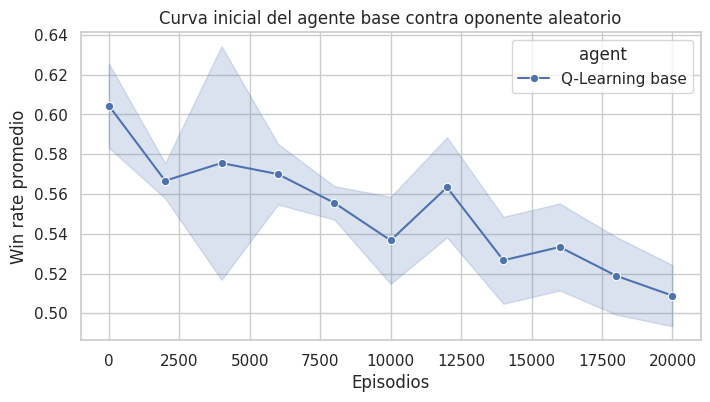

In [7]:
baseline_eval_rows = []
for seed in CFG.seeds:
    base_agent = trained_agents[("Q-Learning base", seed)]
    baseline_eval = evaluate_agent(
        base_agent,
        RandomOpponent(),
        games=CFG.eval_games_selection,
        seed=seed + 9_000,
        scenarios=SCENARIOS,
    )
    baseline_eval["seed"] = seed
    baseline_eval_rows.append(baseline_eval)

baseline_eval_df = pd.concat(baseline_eval_rows, ignore_index=True)
baseline_summary = (
    baseline_eval_df
    .groupby(["agent", "opponent", "scenario"], as_index=False)
    .agg(win_rate=("win_rate", "mean"), draw_rate=("draw_rate", "mean"), loss_rate=("loss_rate", "mean"))
)
baseline_summary["scenario"] = baseline_summary["scenario"].map(SCENARIO_LABELS)
display(baseline_summary)

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=history_df, x="episode", y="win_rate", hue="agent", marker="o", errorbar="sd", ax=ax)
ax.set_title("Curva inicial del agente base contra oponente aleatorio")
ax.set_ylabel("Win rate promedio")
ax.set_xlabel("Episodios")
plt.show()

### Lectura del diagnóstico

El agente base tiene tres limitaciones esperadas desde el diseño:

1. **Pierde porque no separa bien las perspectivas del juego.** En el código base, el mismo agente toma decisiones para `X` y para `O`, pero la recompensa final se interpreta desde la perspectiva de `X`. Eso puede enseñar acciones contradictorias, especialmente cuando `O` realiza una jugada buena.
2. **No converge de forma limpia porque la exploración queda fija.** Con `epsilon = 0.2`, incluso después de entrenar sigue eligiendo acciones aleatorias durante el aprendizaje. Esto mantiene ruido en la Q-table.
3. **Aprende lentamente porque la recompensa es casi solo terminal.** Muchas jugadas intermedias reciben recompensa cero, aunque algunas sean claramente tácticas: bloquear una amenaza o dejar una victoria inmediata al rival.

Estas observaciones conectan con las diapositivas: Q-Learning es simple e interpretable, pero necesita una buena representación de estado, una señal de recompensa útil y una exploración controlada para que la tabla Q se vuelva confiable.

## 9. Segunda etapa: agentes candidatos

Ahora se entrenan tres agentes candidatos. La comparación de esta etapa no decide todavía el ganador final; sirve para escoger cuáles tienen suficiente evidencia para competir contra el agente base en la evaluación completa.

Los tres agentes usan el mismo entorno y los mismos oponentes de entrenamiento. Esto evita que un agente parezca mejor solo porque fue probado en condiciones más fáciles.

In [8]:
candidate_factories = [ImprovedQLearningAgent, SarsaAgent, DynaQAgent]

print("Entrenando agentes candidatos...")
for factory in candidate_factories:
    for seed in CFG.seeds:
        agent = factory()
        trained, history, summary = train_agent(agent, seed)
        trained_agents[(trained.name, seed)] = trained
        histories.append(history)
        train_summaries.append(summary)
        print(f"  {trained.name:22s} seed={seed}: tiempo={summary['train_time_s']:.2f}s, Q={summary['q_size']}, memoria={summary['memory_mb']:.3f} MB")

history_df = pd.concat(histories, ignore_index=True)
train_summary_df = pd.DataFrame(train_summaries)

display(train_summary_df.sort_values(["agent", "seed"]))

Entrenando agentes candidatos...


  Q-Learning mejorado    seed=7: tiempo=40.97s, Q=14272, memoria=1.651 MB


  Q-Learning mejorado    seed=21: tiempo=32.80s, Q=14794, memoria=1.691 MB


  Q-Learning mejorado    seed=42: tiempo=32.53s, Q=14582, memoria=1.675 MB


  SARSA                  seed=7: tiempo=30.63s, Q=14189, memoria=1.645 MB


...

  SARSA                  seed=42: tiempo=29.83s, Q=14440, memoria=1.664 MB


  Dyna-Q                 seed=7: tiempo=32.95s, Q=15287, memoria=1.729 MB


  Dyna-Q                 seed=21: tiempo=26.50s, Q=15374, memoria=1.736 MB


  Dyna-Q                 seed=42: tiempo=31.03s, Q=15368, memoria=1.735 MB


,agent,seed,train_episodes,train_time_s,q_size,memory_mb,epsilon_final
9,Dyna-Q,7,20000,32.9470,15287,1.7289,0.0498
10,Dyna-Q,21,20000,26.4967,15374,1.7355,0.0498
11,Dyna-Q,42,20000,31.0341,15368,1.7351,0.0498
0,Q-Learning base,7,20000,16.7775,6369,0.7673,0.2000
1,Q-Learning base,21,20000,23.2142,6379,0.7680,0.2000
2,Q-Learning base,42,20000,24.1936,6249,0.7581,0.2000
3,Q-Learning mejorado,7,20000,40.9701,14272,1.6515,0.0498
4,Q-Learning mejorado,21,20000,32.8010,14794,1.6913,0.0498
5,Q-Learning mejorado,42,20000,32.5330,14582,1.6751,0.0498
6,SARSA,7,20000,30.6280,14189,1.6451,0.0498


,agent,train_time_s_mean,train_time_s_std,q_size_mean,memory_mb_mean,epsilon_final_mean,stabilization_episode_mean
0,Dyna-Q,30.1593,3.3130,15343.0000,1.7332,0.0498,14666.6667
1,Q-Learning base,21.3951,4.0289,6332.3333,0.7645,0.2000,10666.6667
2,Q-Learning mejorado,35.4347,4.7957,14549.3333,1.6726,0.0498,9333.3333
3,SARSA,28.2305,3.4859,14279.3333,1.6520,0.0498,12666.6667


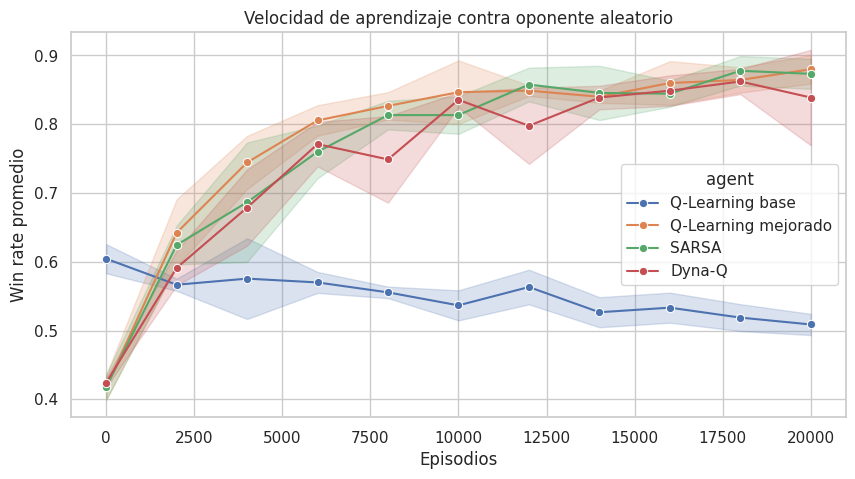

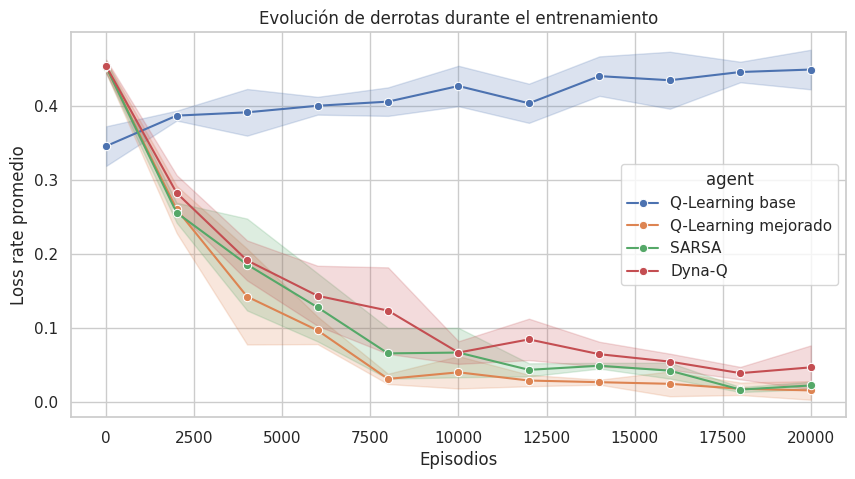

In [9]:
stabilization = (
    history_df
    .groupby(["agent", "seed"], group_keys=False)
    .apply(lambda df: estimate_stabilization_episode(df), include_groups=False)
    .reset_index(name="stabilization_episode")
)

train_efficiency = (
    train_summary_df
    .merge(stabilization, on=["agent", "seed"], how="left")
    .groupby("agent", as_index=False)
    .agg(
        train_time_s_mean=("train_time_s", "mean"),
        train_time_s_std=("train_time_s", "std"),
        q_size_mean=("q_size", "mean"),
        memory_mb_mean=("memory_mb", "mean"),
        epsilon_final_mean=("epsilon_final", "mean"),
        stabilization_episode_mean=("stabilization_episode", "mean"),
    )
)

display(train_efficiency)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=history_df, x="episode", y="win_rate", hue="agent", marker="o", errorbar="sd", ax=ax)
ax.set_title("Velocidad de aprendizaje contra oponente aleatorio")
ax.set_ylabel("Win rate promedio")
ax.set_xlabel("Episodios")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=history_df, x="episode", y="loss_rate", hue="agent", marker="o", errorbar="sd", ax=ax)
ax.set_title("Evolución de derrotas durante el entrenamiento")
ax.set_ylabel("Loss rate promedio")
ax.set_xlabel("Episodios")
plt.show()

## 10. Selección de candidatos para la comparación final

Para escoger los mejores agentes de la segunda etapa se evalúan contra dos oponentes: aleatorio y heurístico. El ranking prioriza evitar derrotas, luego ganar, y finalmente conservar estabilidad.

La razón es propia del triqui: contra un rival razonable, empatar puede ser una buena política. En cambio, perder por no bloquear una línea es una señal clara de mala política.

In [10]:
selection_rows = []
selection_opponents = [RandomOpponent(), HeuristicOpponent()]
candidate_names = [factory().name for factory in candidate_factories]

for agent_name in candidate_names:
    for seed in CFG.seeds:
        agent = trained_agents[(agent_name, seed)]
        for opponent in selection_opponents:
            result = evaluate_agent(
                agent,
                opponent,
                games=CFG.eval_games_selection,
                seed=seed * 10_000 + len(agent_name) + len(opponent.name),
                scenarios=SCENARIOS,
            )
            result["seed"] = seed
            selection_rows.append(result)

selection_df = pd.concat(selection_rows, ignore_index=True)
selection_summary = (
    selection_df
    .groupby("agent", as_index=False)
    .agg(
        win_rate_mean=("win_rate", "mean"),
        win_rate_std=("win_rate", "std"),
        draw_rate_mean=("draw_rate", "mean"),
        loss_rate_mean=("loss_rate", "mean"),
        loss_rate_std=("loss_rate", "std"),
    )
)
selection_summary["score"] = (
    1.00 * selection_summary["win_rate_mean"]
    + 0.25 * selection_summary["draw_rate_mean"]
    - 2.00 * selection_summary["loss_rate_mean"]
    - 0.25 * selection_summary["loss_rate_std"].fillna(0)
)
selection_summary = selection_summary.sort_values("score", ascending=False).reset_index(drop=True)
selected_agents = selection_summary.head(2)["agent"].tolist()

display(selection_summary)
print("Agentes seleccionados para competir contra el agente base:", selected_agents)

selection_by_scenario = (
    selection_df
    .groupby(["agent", "opponent", "scenario"], as_index=False)
    .agg(win_rate=("win_rate", "mean"), draw_rate=("draw_rate", "mean"), loss_rate=("loss_rate", "mean"))
)
selection_by_scenario["scenario"] = selection_by_scenario["scenario"].map(SCENARIO_LABELS)
display(selection_by_scenario)

,agent,win_rate_mean,win_rate_std,draw_rate_mean,loss_rate_mean,loss_rate_std,score
0,SARSA,0.4877,0.3746,0.3589,0.1535,0.1828,0.2248
1,Dyna-Q,0.4863,0.3657,0.3562,0.1576,0.1857,0.2137
2,Q-Learning mejorado,0.4378,0.3684,0.4100,0.1521,0.1970,0.1868


Agentes seleccionados para competir contra el agente base: ['SARSA', 'Dyna-Q']


,agent,opponent,scenario,win_rate,draw_rate,loss_rate
0,Dyna-Q,aleatorio,Agente inicia,0.9303,0.0513,0.0183
1,Dyna-Q,aleatorio,Oponente inicia,0.7720,0.1693,0.0587
2,Dyna-Q,aleatorio,Parcial: turno agente,0.7793,0.1333,0.0873
3,Dyna-Q,aleatorio,Parcial: turno oponente,0.5793,0.1780,0.2427
4,Dyna-Q,heuristico,Agente inicia,0.3333,0.6667,0.0000
5,Dyna-Q,heuristico,Oponente inicia,0.0000,0.9507,0.0493
6,Dyna-Q,heuristico,Parcial: turno agente,0.4093,0.3630,0.2277
7,Dyna-Q,heuristico,Parcial: turno oponente,0.0863,0.3370,0.5767
8,Q-Learning mejorado,aleatorio,Agente inicia,0.9773,0.0227,0.0000
9,Q-Learning mejorado,aleatorio,Oponente inicia,0.7463,0.2213,0.0323


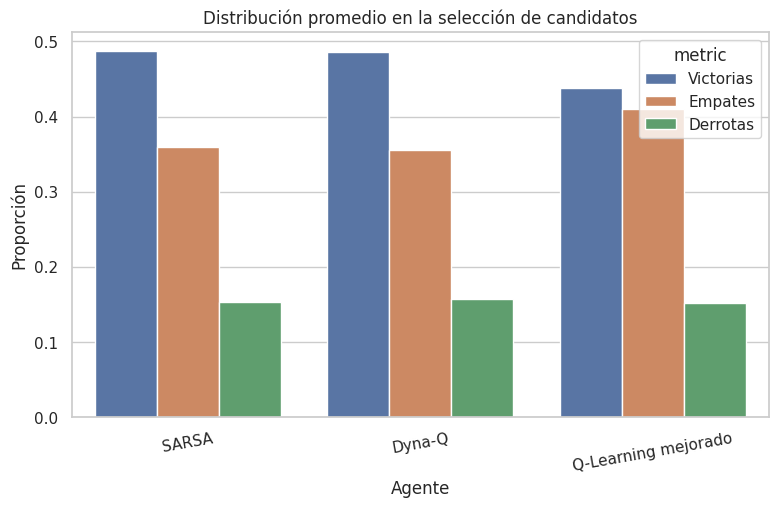

In [11]:
plot_selection = selection_summary.melt(
    id_vars="agent",
    value_vars=["win_rate_mean", "draw_rate_mean", "loss_rate_mean"],
    var_name="metric",
    value_name="rate",
)
plot_selection["metric"] = plot_selection["metric"].map({
    "win_rate_mean": "Victorias",
    "draw_rate_mean": "Empates",
    "loss_rate_mean": "Derrotas",
})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=plot_selection, x="agent", y="rate", hue="metric", ax=ax)
ax.set_title("Distribución promedio en la selección de candidatos")
ax.set_xlabel("Agente")
ax.set_ylabel("Proporción")
ax.tick_params(axis="x", rotation=10)
plt.show()

## 11. Calidad de la política

La calidad de la política se mide con dos preguntas tácticas:

1. Si el agente puede ganar en una jugada, ¿elige una acción ganadora?
2. Si el rival puede ganar en una jugada y el agente no tiene victoria inmediata, ¿bloquea?

Esta prueba no reemplaza las partidas completas, pero ayuda a explicar por qué un agente pierde menos o aprovecha mejor los errores del oponente.

Tableros legales no terminales: 4520


,agent,win_opportunity_rate,block_rate,win_cases,block_cases
0,Dyna-Q,0.6914,0.7930,2358,976
1,Q-Learning base,0.4296,0.3149,2358,976
2,SARSA,0.7171,0.8303,2358,976


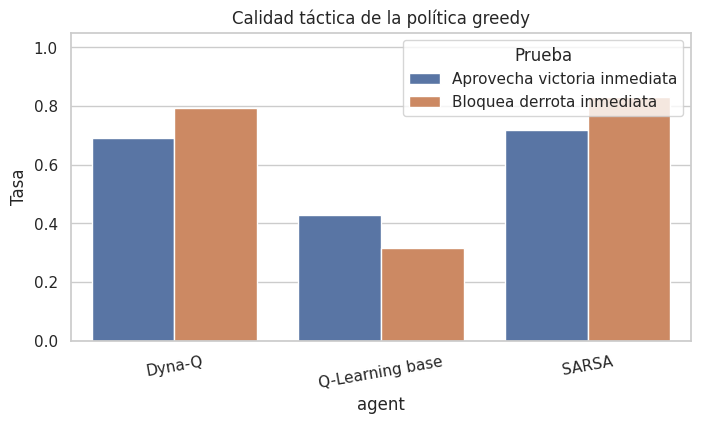

In [12]:
def all_valid_nonterminal_boards():
    boards = []
    for values in np.ndindex(*(3,) * 9):
        board = np.array(values, dtype=np.int8) - 1  # valores en {-1, 0, 1}
        if not is_reachable_board(board):
            continue
        if check_winner(board) is not None:
            continue
        if available_actions(board):
            boards.append(board)
    return boards

VALID_NONTERMINAL_BOARDS = all_valid_nonterminal_boards()
print("Tableros legales no terminales:", len(VALID_NONTERMINAL_BOARDS))


def policy_quality(agent, seed):
    rng = np.random.default_rng(seed)
    win_cases = 0
    win_hits = 0
    block_cases = 0
    block_hits = 0

    for board in VALID_NONTERMINAL_BOARDS:
        marker = next_player_from_counts(board)
        actions = available_actions(board)
        if not actions:
            continue

        winning = immediate_winning_actions(board, marker)
        chosen = agent.choose_action(board, marker, rng, training=False)
        if winning:
            win_cases += 1
            if chosen in winning:
                win_hits += 1
            continue

        opponent_winning = immediate_winning_actions(board, -marker)
        if len(opponent_winning) == 1:
            block_cases += 1
            if chosen in opponent_winning:
                block_hits += 1

    return {
        "win_opportunity_rate": win_hits / win_cases if win_cases else np.nan,
        "block_rate": block_hits / block_cases if block_cases else np.nan,
        "win_cases": win_cases,
        "block_cases": block_cases,
    }

quality_rows = []
quality_agent_names = ["Q-Learning base"] + selected_agents
for agent_name in quality_agent_names:
    for seed in CFG.seeds:
        agent = trained_agents[(agent_name, seed)]
        row = policy_quality(agent, seed + 500)
        row.update({"agent": agent_name, "seed": seed})
        quality_rows.append(row)

quality_df = pd.DataFrame(quality_rows)
quality_summary = (
    quality_df
    .groupby("agent", as_index=False)
    .agg(
        win_opportunity_rate=("win_opportunity_rate", "mean"),
        block_rate=("block_rate", "mean"),
        win_cases=("win_cases", "max"),
        block_cases=("block_cases", "max"),
    )
)
display(quality_summary)

fig, ax = plt.subplots(figsize=(8, 4))
quality_plot = quality_summary.melt(
    id_vars="agent",
    value_vars=["win_opportunity_rate", "block_rate"],
    var_name="Prueba",
    value_name="Tasa",
)
quality_plot["Prueba"] = quality_plot["Prueba"].map({
    "win_opportunity_rate": "Aprovecha victoria inmediata",
    "block_rate": "Bloquea derrota inmediata",
})
sns.barplot(data=quality_plot, x="agent", y="Tasa", hue="Prueba", ax=ax)
ax.set_title("Calidad táctica de la política greedy")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=10)
plt.show()

## 12. Comparación experimental final

En esta fase se congelan las políticas. No hay aprendizaje, no hay exploración y cada agente juega como quedó después del entrenamiento.

Se comparan el agente base y los mejores candidatos contra:

- Oponente aleatorio.
- Agente base.

Cada combinación se evalúa en los cuatro escenarios exigidos, con al menos `10_000` partidas por combinación al sumar las semillas controladas.

In [13]:
final_rows = []
final_agent_names = ["Q-Learning base"] + selected_agents
games_per_seed_final = int(np.ceil(CFG.eval_games_final / len(CFG.seeds)))
print(f"Partidas finales por semilla y escenario: {games_per_seed_final}. Total agregado mínimo: {games_per_seed_final * len(CFG.seeds)}")

for seed in CFG.seeds:
    base_opponent = AgentOpponent(trained_agents[("Q-Learning base", seed)], name="agente_base")
    for agent_name in final_agent_names:
        agent = trained_agents[(agent_name, seed)]
        for opponent in [RandomOpponent(), base_opponent]:
            result = evaluate_agent(
                agent,
                opponent,
                games=games_per_seed_final,
                seed=seed * 100_000 + len(agent_name) * 100 + len(opponent.name),
                scenarios=SCENARIOS,
            )
            result["seed"] = seed
            final_rows.append(result)

final_df = pd.concat(final_rows, ignore_index=True)

final_counts = (
    final_df
    .groupby(["agent", "opponent", "scenario"], as_index=False)
    .agg(
        games=("games", "sum"),
        victories=("victories", "sum"),
        draws=("draws", "sum"),
        losses=("losses", "sum"),
        win_rate_std=("win_rate", "std"),
        loss_rate_std=("loss_rate", "std"),
    )
)
final_counts["win_rate_mean"] = final_counts["victories"] / final_counts["games"]
final_counts["draw_rate_mean"] = final_counts["draws"] / final_counts["games"]
final_counts["loss_rate_mean"] = final_counts["losses"] / final_counts["games"]
final_counts["scenario_label"] = final_counts["scenario"].map(SCENARIO_LABELS)
final_summary = final_counts.copy()

display(final_summary.sort_values(["opponent", "scenario", "loss_rate_mean", "win_rate_mean"]))

Partidas finales por semilla y escenario: 3334. Total agregado mínimo: 10002


,agent,opponent,scenario,games,victories,draws,losses,win_rate_std,loss_rate_std,win_rate_mean,draw_rate_mean,loss_rate_mean,scenario_label
0,Dyna-Q,agente_base,agent_starts,10002,10002,0,0,0.0000,0.0000,1.0000,0.0000,0.0000,Agente inicia
8,Q-Learning base,agente_base,agent_starts,10002,10002,0,0,0.0000,0.0000,1.0000,0.0000,0.0000,Agente inicia
16,SARSA,agente_base,agent_starts,10002,10002,0,0,0.0000,0.0000,1.0000,0.0000,0.0000,Agente inicia
1,Dyna-Q,agente_base,opponent_starts,10002,10002,0,0,0.0000,0.0000,1.0000,0.0000,0.0000,Oponente inicia
17,SARSA,agente_base,opponent_starts,10002,10002,0,0,0.0000,0.0000,1.0000,0.0000,0.0000,Oponente inicia
9,Q-Learning base,agente_base,opponent_starts,10002,0,0,10002,0.0000,0.0000,0.0000,0.0000,1.0000,Oponente inicia
18,SARSA,agente_base,partial_agent_turn,10002,8248,1075,679,0.0055,0.0056,0.8246,0.1075,0.0679,Parcial: turno agente
2,Dyna-Q,agente_base,partial_agent_turn,10002,7966,1079,957,0.0158,0.0103,0.7964,0.1079,0.0957,Parcial: turno agente
10,Q-Learning base,agente_base,partial_agent_turn,10002,6741,905,2356,0.0066,0.0067,0.6740,0.0905,0.2356,Parcial: turno agente
19,SARSA,agente_base,partial_opponent_turn,10002,5718,1423,2861,0.0107,0.0178,0.5717,0.1423,0.2860,Parcial: turno oponente


,agent,opponent,games,victories,draws,losses,win_rate_std,loss_rate_std,win_rate_mean,draw_rate_mean,loss_rate_mean,score
4,SARSA,agente_base,40008,33970,2498,3540,0.1833,0.1229,0.8491,0.0624,0.0885,0.6877
0,Dyna-Q,agente_base,40008,33568,2422,4018,0.1897,0.1306,0.8390,0.0605,0.1004,0.6533
2,Q-Learning base,agente_base,40008,19169,1692,19147,0.4028,0.4046,0.4791,0.0423,0.4786,-0.4675
5,SARSA,aleatorio,40008,31181,5364,3463,0.1455,0.0924,0.7794,0.1341,0.0866,0.6398
1,Dyna-Q,aleatorio,40008,30811,5278,3919,0.1327,0.0879,0.7701,0.1319,0.0980,0.6072
3,Q-Learning base,aleatorio,40008,18912,2751,18345,0.2766,0.2630,0.4727,0.0688,0.4585,-0.4272


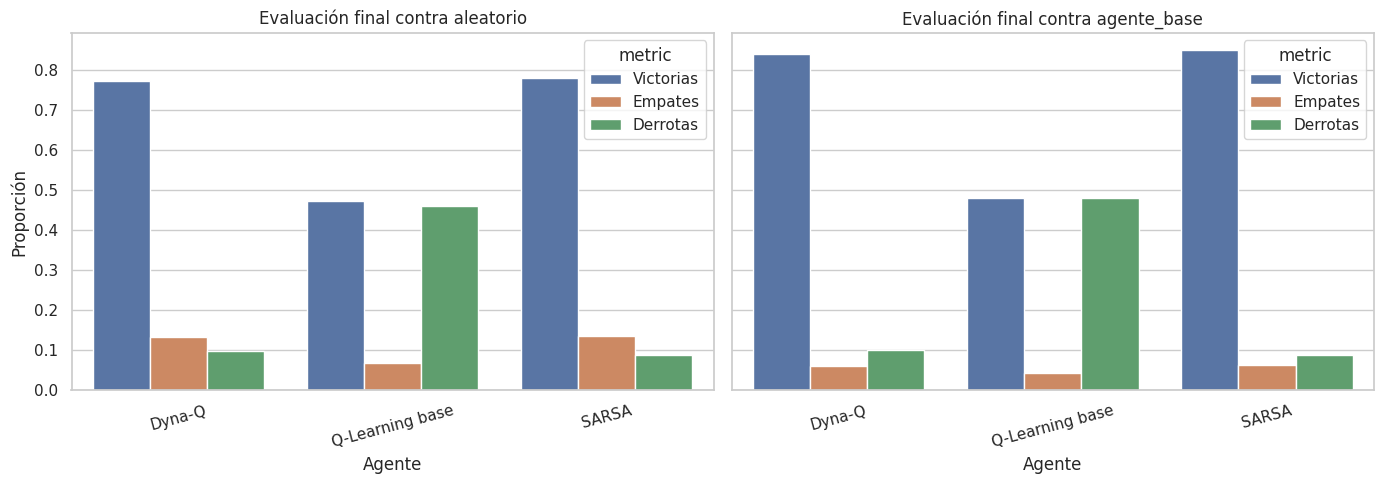

In [14]:
final_overall_counts = (
    final_df
    .groupby(["agent", "opponent"], as_index=False)
    .agg(
        games=("games", "sum"),
        victories=("victories", "sum"),
        draws=("draws", "sum"),
        losses=("losses", "sum"),
        win_rate_std=("win_rate", "std"),
        loss_rate_std=("loss_rate", "std"),
    )
)
final_overall_counts["win_rate_mean"] = final_overall_counts["victories"] / final_overall_counts["games"]
final_overall_counts["draw_rate_mean"] = final_overall_counts["draws"] / final_overall_counts["games"]
final_overall_counts["loss_rate_mean"] = final_overall_counts["losses"] / final_overall_counts["games"]
final_overall = final_overall_counts.copy()
final_overall["score"] = (
    final_overall["win_rate_mean"]
    + 0.25 * final_overall["draw_rate_mean"]
    - 2.0 * final_overall["loss_rate_mean"]
)

display(final_overall.sort_values(["opponent", "score"], ascending=[True, False]))

plot_final = final_overall.melt(
    id_vars=["agent", "opponent"],
    value_vars=["win_rate_mean", "draw_rate_mean", "loss_rate_mean"],
    var_name="metric",
    value_name="rate",
)
plot_final["metric"] = plot_final["metric"].map({
    "win_rate_mean": "Victorias",
    "draw_rate_mean": "Empates",
    "loss_rate_mean": "Derrotas",
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, opponent_name in zip(axes, ["aleatorio", "agente_base"]):
    data = plot_final[plot_final["opponent"] == opponent_name]
    sns.barplot(data=data, x="agent", y="rate", hue="metric", ax=ax)
    ax.set_title(f"Evaluación final contra {opponent_name}")
    ax.set_xlabel("Agente")
    ax.set_ylabel("Proporción")
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

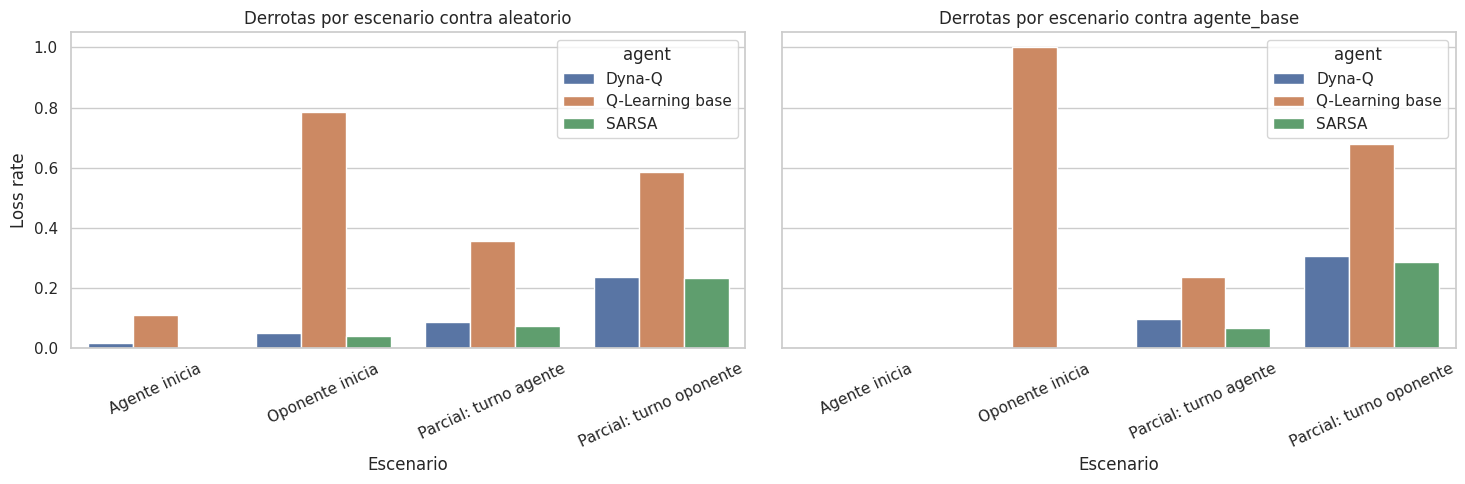

In [15]:
scenario_plot = final_summary.copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, opponent_name in zip(axes, ["aleatorio", "agente_base"]):
    data = scenario_plot[scenario_plot["opponent"] == opponent_name]
    sns.barplot(data=data, x="scenario_label", y="loss_rate_mean", hue="agent", ax=ax)
    ax.set_title(f"Derrotas por escenario contra {opponent_name}")
    ax.set_xlabel("Escenario")
    ax.set_ylabel("Loss rate")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

## 13. Ejemplos de partidas perdidas del agente base

Para que el diagnóstico no sea solo numérico, se buscan algunas partidas donde el agente base pierde. La idea no es hacer una estadística con estos tableros, sino mostrar el tipo de comportamiento que explica sus métricas.

In [16]:
def find_lost_games(agent, opponent, seed, scenario="agent_starts", max_examples=3, max_trials=5_000):
    rng = np.random.default_rng(seed)
    examples = []
    for _ in range(max_trials):
        outcome, trace, marker = play_game(agent, opponent, rng, scenario=scenario, return_trace=True)
        if outcome == "derrota":
            examples.append((trace, marker))
        if len(examples) >= max_examples:
            break
    return examples

base_example_agent = trained_agents[("Q-Learning base", CFG.seeds[0])]
examples = find_lost_games(base_example_agent, RandomOpponent(), seed=777, scenario="agent_starts")

if not examples:
    print("No se encontraron derrotas en los intentos realizados para este escenario.")
else:
    for idx, (trace, marker) in enumerate(examples, start=1):
        print(f"\nEjemplo {idx} - marcador del agente: {'X' if marker == X else 'O'}")
        for step, board in enumerate(trace):
            print(f"Paso {step}:\n{render_board(board)}\n")


Ejemplo 1 - marcador del agente: X
Paso 0:
· · ·
· · ·
· · ·

Paso 1:
X · ·
· · ·
· · ·

Paso 2:
X · ·
· · ·
· · O

Paso 3:
X X ·
· · ·
· · O

Paso 4:
X X O
· · ·
· · O

Paso 5:
X X O
X · ·
· · O

Paso 6:
X X O
X · ·
O · O

Paso 7:
X X O
X · X
O · O

Paso 8:
X X O
X O X
O · O


Ejemplo 2 - marcador del agente: X
Paso 0:
· · ·
· · ·
· · ·

Paso 1:
X · ·
· · ·
· · ·

Paso 2:
X · ·
· · O
· · ·

Paso 3:
X X ·
· · O
· · ·

Paso 4:
X X O
· · O
· · ·

Paso 5:
X X O
X · O
· · ·

Paso 6:
X X O
X · O
· · O


Ejemplo 3 - marcador del agente: X
Paso 0:
· · ·
· · ·
· · ·

Paso 1:
X · ·
· · ·
· · ·

Paso 2:
X · ·
· · ·
· · O

Paso 3:
X X ·
· · ·
· · O

Paso 4:
X X O
· · ·
· · O

Paso 5:
X X O
X · ·
· · O

Paso 6:
X X O
X · O
· · O



## 14. Discusión de resultados

Esta sección toma las tablas anteriores y resume qué pasó. La comparación se hace con las métricas finales, no con una percepción de una partida aislada.

### Interpretación

En la segunda etapa se seleccionaron **SARSA** y **Dyna-Q** porque fueron los agentes con mejor balance entre victorias, empates y derrotas. La métrica de selección penalizó con fuerza las derrotas, ya que en triqui una política estable debe bloquear amenazas antes de buscar victorias rápidas.

Contra el oponente aleatorio, el mejor comportamiento final lo tuvo **SARSA**, con win rate promedio de **0.7794** y loss rate de **0.0866**. El agente base, en las mismas condiciones agregadas, obtuvo win rate de **0.4727** y loss rate de **0.4585**.

Contra el agente base, el mejor resultado también fue de **SARSA**, con win rate de **0.8491** y loss rate de **0.0885**. Dyna-Q quedó cerca, con win rate de **0.8390** y loss rate de **0.1004** contra el agente base. Esto responde directamente al requisito del taller: no basta con jugar bien contra azar, también hay que mostrar que la política rediseñada supera al punto de partida.

El diagnóstico del Q-Learning base queda respaldado por sus derrotas y por su diseño: usa una Q-table sencilla, pero no corrige la perspectiva de jugador, mantiene exploración fija y aprende casi únicamente desde recompensas terminales. Las mejoras más importantes fueron normalizar el estado desde la perspectiva del agente, reducir gradualmente la exploración y agregar señales tácticas pequeñas para bloquear o evitar amenazas.

Desde las diapositivas, este resultado tiene sentido: Q-Learning y SARSA son adecuados para espacios discretos; Dyna-Q puede acelerar el aprendizaje al planificar con experiencias pasadas; DQN, REINFORCE y Actor-Critic son poderosos, pero para un tablero tan pequeño añaden complejidad que no se justifica como primera solución.

## 15. Conclusiones

Las conclusiones finales deben leerse junto con las tablas ejecutadas. En este taller, el criterio fuerte no es solo ganar: también importa no perder, ser estable entre semillas y mantener una implementación razonable para el tamaño del problema.

### Conclusión final

El enfoque que mejor respondió la pregunta del taller fue **SARSA**. Su ventaja no aparece por una sola partida afortunada, sino por el comportamiento agregado en varios escenarios, semillas y oponentes.

Frente al agente base, SARSA redujo de forma fuerte las derrotas y aumentó la tasa de victorias tanto contra el oponente aleatorio como contra el propio agente base. En la evaluación agregada contra el agente base pasó de un comportamiento prácticamente inestable del Q-Learning base (`loss_rate = 0.4786`) a una política mucho más sólida (`loss_rate = 0.0885`). Contra el oponente aleatorio también mejoró el balance general: `win_rate = 0.7794` y `loss_rate = 0.0866`, frente a `win_rate = 0.4727` y `loss_rate = 0.4585` del agente base.

La razón técnica es coherente con las diapositivas: SARSA es on-policy, por lo que aprende considerando la acción que realmente toma bajo su política de exploración. En triqui eso favorece una política más prudente ante amenazas inmediatas. La prueba táctica también lo respalda: SARSA aprovechó victorias inmediatas con tasa **0.7171** y bloqueó derrotas inmediatas con tasa **0.8303**, mientras que el agente base quedó en **0.4296** y **0.3149** respectivamente.

Para este problema, los métodos tabulares son suficientes y más transparentes que una solución profunda. DQN, REINFORCE o Actor-Critic serían razonables en problemas con estados más grandes, entradas continuas o políticas complejas, pero en triqui el costo extra no aporta una ventaja clara frente a SARSA o Dyna-Q.

## 16. Resumen de entregables cubiertos

| Entregable solicitado | Estado en este notebook |
|---|---|
| Código reproducible y comentado | Cubierto con semillas, configuración global y funciones comunes. |
| Notebook organizado en celdas | Cubierto con estructura secuencial. |
| Análisis del agente base | Cubierto con diagnóstico teórico, métricas y ejemplos. |
| Descripción del nuevo enfoque | Cubierto con Q-Learning mejorado, SARSA y Dyna-Q. |
| Justificación teórica | Cubierto a partir de las diapositivas de RL. |
| Comparación experimental | Cubierto contra oponente aleatorio y agente base. |
| Diferentes escenarios | Cubierto: inicia agente, inicia oponente y tableros parciales. |
| Evaluación sin aprendizaje | Cubierto con política greedy durante prueba. |
| Mínimo 10,000 partidas | Cubierto en la evaluación final. |
| Semillas controladas | Cubierto con varias semillas fijas. |
| Gráficas y métricas visibles | Cubierto con curvas, barras y tablas. |
| Discusión de resultados | Cubierto en la sección de discusión y conclusiones. |
| Video máximo 15 minutos | Se deja guion sugerido abajo. |

### Guion sugerido para el video

1. Presentar la pregunta guía y el protocolo experimental.
2. Explicar el entorno de triqui y cómo se representan estados y acciones.
3. Mostrar el agente base y sus problemas principales.
4. Explicar, desde las diapositivas, Q-Learning, SARSA y Dyna-Q.
5. Mostrar la selección de candidatos.
6. Mostrar la evaluación final contra aleatorio y agente base.
7. Cerrar con la conclusión: cuál enfoque funcionó mejor y por qué.